# Estimating the misorientation angle of ocean-bottom seismometers using P-wave polarization from seismic events

**Goal.** This notebook demonstrates a reproducible workflow to estimate the horizontal misorientation angle of a broadband ocean-bottom seismometer (OBS) using teleseismic P-wave polarization and `OrientPy`.

The workflow is designed for a quasi-live conference demonstration:

1. Select a public OBS station from an FDSN archive.
2. Build a station database (`StDb`) from FDSN metadata.
3. Count the teleseismic events matching the selected catalogue criteria.
4. Run the `OrientPy` BNG/P-wave transverse-energy minimization workflow.
5. Apply quality control and obtain the final misorientation estimate and uncertainty.

**Recommended live strategy.** Run the heavy `bng_calc` step once before the talk. During the talk, show the parameter cell, the event-count cell, and re-run `bng_average` on the cached `BNG_RESULTS` directory. The Wi-Fi at conferences is not part of the scientific method.

## 1. Why orientation matters

Three-component seismic analysis assumes that the two horizontal components are correctly tied to geographic North and East. If the true azimuth of the instrument horizontal axis is unknown, radial/transverse rotations are biased. That bias propagates into analyses such as receiver functions, moment-tensor inversions, shear-wave splitting, surface-wave polarization, and any measurement that depends on the separation of radial and transverse motion.

This is particularly relevant for OBS deployments. On land, the sensor can often be aligned manually. On the seafloor, the final azimuth after deployment is commonly unknown or only weakly constrained. Therefore, the orientation must often be estimated a posteriori from the recorded wavefield.

Here we use the P-wave polarization method implemented in `OrientPy`, specifically the BNG workflow after Braunmiller, Nabelek and Ghods (2020). `OrientPy` estimates station orientation as the azimuth of horizontal component `1` or `N`.

## 2. Geometry and sign convention

The OBS misorientation angle is defined here as

$$
\phi_{\mathrm{Mis}} = \phi_{\mathrm{Teor}} - \phi_{\mathrm{App}},
$$

where:

- $\phi_{\mathrm{Teor}}$ is the theoretical back-azimuth from the station to the earthquake, measured clockwise from geographic North.
- $\phi_{\mathrm{App}}$ is the apparent back-azimuth inferred from the horizontal sensor components.
- $\phi_{\mathrm{Mis}}$ is the clockwise azimuth of the instrument `H1` axis relative to geographic North.

For this notebook we assume the OBS horizontal convention:

$$
H2 = H1 + 90^\circ \quad \mathrm{clockwise}.
$$

This corresponds to the left-handed horizontal convention listed as the default in the relevant `OrientPy` command-line option: `HZ, H2 90 CW H1`. In the current documentation the coordinate-system option is also marked as not yet implemented, so this notebook assumes the documented default convention rather than treating this option as a general run-time converter between arbitrary channel conventions.

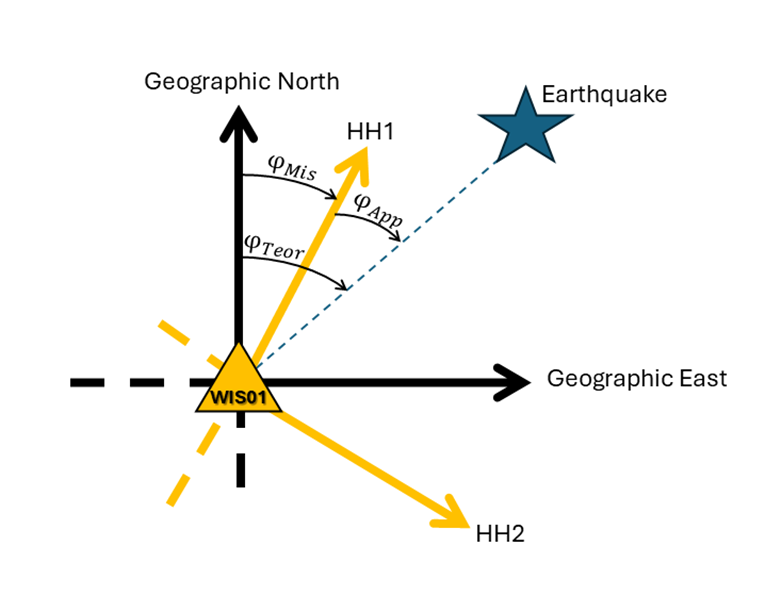

## 3. Method: P-wave transverse-energy minimization

For a teleseismic P wave in a locally simple medium, particle motion should be concentrated mostly in the vertical-radial plane. After rotating the two horizontal components by the correct azimuth, the transverse component should contain minimal P-wave energy.

The basic workflow is:

1. Predict the P-arrival time for each earthquake-station pair.
2. Extract a short time window around the predicted P arrival.
3. Rotate the two horizontal components over a trial angle grid.
4. For each trial angle, compute the transverse-component RMS energy.
5. Select the angle that minimizes transverse energy.
6. Resolve the 180° ambiguity using the zero-lag correlation between the rotated radial and vertical components.
7. Combine event-wise estimates using quality-control thresholds and bootstrap uncertainty.

`OrientPy` exposes this workflow through two command-line tools:

- `bng_calc`: downloads/processes station-event seismograms and estimates event-wise P-wave orientation values.
- `bng_average`: applies quality control and returns the mean orientation, uncertainty, and number of accepted event estimates.

## 4. Install dependencies

The official `OrientPy` documentation recommends `ObsPy`, `StDb`, and `geographiclib`, and installation from the GitHub repository. This cell is intentionally explicit because Colab environments change over time.

After installation, if a command is not found, restart the runtime and run this section again.

In [ ]:
%%capture
!python -m pip install -q --upgrade pip
!python -m pip install -q numpy scipy matplotlib pandas obspy geographiclib cartopy
!python -m pip install -q git+https://github.com/schaefferaj/stdb
!python -m pip install -q git+https://github.com/nfsi-canada/orientpy


In [ ]:
import shutil
import subprocess
import sys
from pathlib import Path

print(sys.version)
for exe in ["query_fdsn_stdb", "ls_stdb", "bng_calc", "bng_average"]:
    print(f"{exe:16s} -> {shutil.which(exe)}")

## 5. Select a public OBS station

For the live demonstration, open IRIS/EarthScope GMAP and select a station with three-component OBS channels, typically something like `HHZ`, `HH1`, and `HH2` or `BHZ`, `BH1`, and `BH2`.

GMAP example view:

https://ds.iris.edu/gmap/#network=*&maxlat=46.6342&maxlon=19.8146&minlat=34.8499&minlon=6.7848&drawingmode=box&planet=earth

The default values below use the `YH.LOBS3` station from the `OrientPy` tutorial. For the conference, replace these parameters with the station selected live from GMAP.

In [ ]:
# ----------------------------------------------------------------------------
# Station metadata
# ----------------------------------------------------------------------------
NETWORK = "YH"       # Example from OrientPy tutorial. Replace during live demo.
STATION = "LOBS3"
CHANNEL_PREFIX = "HH"  # HH -> HHZ/HH1/HH2. Use BH for BHZ/BH1/BH2 if needed.
LOCATION_CODE = "*"    # Use '*' unless you need a specific location code.

# Station database output name. query_fdsn_stdb will create <basename>.pkl
STDB_BASENAME = f"{NETWORK}_{STATION}_stdb"
STDB_FILE = f"{STDB_BASENAME}.pkl"

# FDSN services. 'IRIS' is kept for compatibility with the OrientPy tutorial.
# For some stations, 'EARTHSCOPE', 'ORFEUS', 'EIDA', 'INGV', or another FDSN node may be needed.
SERVER_CAT = "IRIS"
SERVER_WF = "IRIS"

# ----------------------------------------------------------------------------
# Time span. Keep it short for live tests; use the full deployment for final runs.
# ----------------------------------------------------------------------------
START = "2014-05-15"
END = "2015-06-23"

# ----------------------------------------------------------------------------
# Event selection: teleseismic P-wave setup
# ----------------------------------------------------------------------------
MIN_MAG = 6.0
MAX_MAG = 9.0
MIN_DIST = 30.0      # degrees; teleseismic lower bound
MAX_DIST = 175.0     # degrees
MAX_DEP = 1000.0     # km

# ----------------------------------------------------------------------------
# P-wave processing parameters
# ----------------------------------------------------------------------------
P_TIMES = "-5.,15."  # seconds relative to theoretical P arrival used for measurement
WINDOW = 60.0        # seconds of waveform request/processing window
BANDPASS = "0.04,0.10"  # Hz; long-period P wave example
DPHI = 0.1           # degrees; angular grid spacing
ZCOMP = "Z"
COORD_SYSTEM = 2     # 2 = HZ, H2 90 degrees clockwise from H1; documented default in OrientPy.

# ----------------------------------------------------------------------------
# bng_average quality-control thresholds
# ----------------------------------------------------------------------------
SNR_THRESHOLD = 5.0
CC_THRESHOLD = 0.5
TR_THRESHOLD = 0.5
RZ_THRESHOLD = -1.0

# ----------------------------------------------------------------------------
# Quasi-live toggles
# ----------------------------------------------------------------------------
RUN_BNG_CALC = True       # Heavy step: downloads/processes all station-event waveforms.
RUN_BNG_AVERAGE = True    # Fast if BNG_RESULTS already exists.

### Parameter notes

- **Bandpass filter (`BANDPASS`)** controls the frequency content used to measure P-wave polarization. Long-period bands are often more stable for teleseismic P waves; higher-frequency bands can be useful but are more sensitive to scattering, local structure, and noise.
- **P window (`P_TIMES`)** defines the time interval around the theoretical P arrival used for the polarization estimate. Too short means unstable estimates; too long can include converted/scattered phases.
- **Angular grid (`DPHI`)** controls the rotation search resolution. Smaller values are more precise but slower.
- **Magnitude and distance range** control the candidate earthquake catalogue. Teleseismic P-wave applications commonly use large events and distances beyond local/regional ranges.
- **SNR threshold** rejects low-quality P arrivals.
- **CC threshold** uses vertical-radial correlation to help retain physically coherent P-wave particle motion and resolve the 180° ambiguity.
- **T/R threshold** rejects events for which transverse energy remains too high after rotation.
- **R/Z threshold** is an additional amplitude-ratio control; keeping it permissive is useful during exploratory runs.

## 6. Build the `StDb` station database

`OrientPy` command-line scripts require a station database. Here we generate it directly from FDSN station metadata using `query_fdsn_stdb`.

In [ ]:
from pathlib import Path
import subprocess
import shlex

cmd = [
    "query_fdsn_stdb",
    "-N", NETWORK,
    "-S", STATION,
    STDB_BASENAME,
]

print("Running:")
print(" ".join(shlex.quote(x) for x in cmd))

with open("stdb_query.log", "w") as log:
    proc = subprocess.run(cmd, stdout=log, stderr=subprocess.PIPE, text=True)

print("Return code:", proc.returncode)
if proc.stderr.strip():
    print("STDERR:")
    print(proc.stderr)

if Path(STDB_FILE).exists():
    print(f"Created: {STDB_FILE}")
else:
    print(f"Missing: {STDB_FILE}. Check network/station code and FDSN availability.")

In [ ]:
if Path(STDB_FILE).exists():
    !ls_stdb {STDB_FILE}
else:
    print("No StDb file found. Fix the station parameters before continuing.")

## 7. Count candidate teleseismic events

This cell queries the event catalogue and filters events by epicentral distance from the selected station. The number printed here is the number of candidate events before waveform availability and `OrientPy` quality control are applied.

The number retained by `bng_average` will normally be smaller, because some events lack complete 3-component data or fail QC.

In [ ]:
import pandas as pd
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
from obspy.geodetics import gps2dist_azimuth, locations2degrees

client_cat = Client(SERVER_CAT)
client_wf = Client(SERVER_WF)

start = UTCDateTime(START)
end = UTCDateTime(END)

# Get station coordinates. Use the channel pattern to select the relevant sensor family.
inv = client_wf.get_stations(
    network=NETWORK,
    station=STATION,
    location=LOCATION_CODE,
    channel=f"{CHANNEL_PREFIX}?",
    starttime=start,
    endtime=end,
    level="station",
)

sta = inv[0][0]
sta_lat = float(sta.latitude)
sta_lon = float(sta.longitude)
print(f"Station: {NETWORK}.{STATION}")
print(f"Latitude:  {sta_lat:.4f}")
print(f"Longitude: {sta_lon:.4f}")

cat = client_cat.get_events(
    starttime=start,
    endtime=end,
    minmagnitude=MIN_MAG,
    maxmagnitude=MAX_MAG,
    maxdepth=MAX_DEP,
)

rows = []
for ev in cat:
    org = ev.preferred_origin() or ev.origins[0]
    mag = ev.preferred_magnitude() or ev.magnitudes[0]

    dist_deg = locations2degrees(sta_lat, sta_lon, org.latitude, org.longitude)
    if not (MIN_DIST <= dist_deg <= MAX_DIST):
        continue

    # ObsPy returns: distance_m, azimuth_from_station_to_event, back_azimuth_from_event_to_station.
    # For orientation work at the station, the useful theoretical direction is the
    # station-to-earthquake azimuth, commonly called theoretical back-azimuth in this context.
    _, station_to_event_az, event_to_station_az = gps2dist_azimuth(
        sta_lat, sta_lon, org.latitude, org.longitude
    )

    rows.append({
        "origin_time": org.time.datetime.isoformat(timespec="seconds"),
        "latitude": float(org.latitude),
        "longitude": float(org.longitude),
        "depth_km": None if org.depth is None else float(org.depth) / 1000.0,
        "magnitude": None if mag is None else float(mag.mag),
        "dist_deg": float(dist_deg),
        "baz_deg": float(station_to_event_az),
        "event_to_station_az_deg": float(event_to_station_az),
    })

events_df = pd.DataFrame(rows).sort_values("origin_time").reset_index(drop=True)
print(f"Number of catalogue events matching magnitude/depth/distance criteria: {len(events_df)}")

events_df.head(12)


### Catalogue geometry map

This map is only a pre-processing diagnostic: it shows the station and all catalogue events that pass the magnitude, depth, and epicentral-distance criteria. The number shown here is not the final number of usable orientation measurements, because `bng_calc` and `bng_average` will later reject events with missing waveforms, gaps, low signal-to-noise ratio, poor radial-vertical correlation, or excessive transverse energy.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "cartopy"])
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

from geographiclib.geodesic import Geodesic
from matplotlib.lines import Line2D


def small_circle(lon0, lat0, radius_deg, n=721):
    """Return lon/lat points along a geodesic small circle around the station."""
    earth_radius_km_per_deg = 111.195
    distance_m = radius_deg * earth_radius_km_per_deg * 1000.0
    azimuths = np.linspace(0, 360, n)
    lons, lats = [], []
    for az in azimuths:
        g = Geodesic.WGS84.Direct(lat0, lon0, float(az), distance_m)
        lats.append(g["lat2"])
        lons.append(g["lon2"])
    return np.array(lons), np.array(lats)


def magnitude_to_size(mag):
    """Marker size scaling for visual comparison only."""
    mag = np.asarray(mag, dtype=float)
    return 18.0 + 18.0 * np.clip(mag - MIN_MAG + 0.2, 0.1, None) ** 2


if events_df.empty:
    raise ValueError("No catalogue events to plot. Relax MIN_MAG, distance range, time window, or server selection.")

plot_df = events_df.copy()
plot_df["depth_km"] = plot_df["depth_km"].astype(float)
plot_df["magnitude"] = plot_df["magnitude"].astype(float)

proj = ccrs.AzimuthalEquidistant(central_longitude=sta_lon, central_latitude=sta_lat)
fig = plt.figure(figsize=(9.5, 9.5))
ax = plt.axes(projection=proj)

# Plot up to the selected maximum distance, plus a small margin.
max_radius_deg = min(MAX_DIST, 179.0)
map_radius_m = max_radius_deg * 111.195 * 1000.0 * 1.03
ax.set_xlim(-map_radius_m, map_radius_m)
ax.set_ylim(-map_radius_m, map_radius_m)

ax.add_feature(cfeature.OCEAN, zorder=0)
ax.add_feature(cfeature.LAND, zorder=1, linewidth=0.2, edgecolor="0.35")
ax.coastlines(linewidth=0.6, zorder=2)

# Epicentral-distance rings.
ring_values = [45, 90, 135]
if MAX_DIST not in ring_values:
    ring_values.append(int(MAX_DIST) if float(MAX_DIST).is_integer() else MAX_DIST)

for radius_deg in ring_values:
    if radius_deg <= 0 or radius_deg > 179:
        continue
    lons, lats = small_circle(sta_lon, sta_lat, radius_deg)
    ax.plot(lons, lats, transform=ccrs.Geodetic(), linewidth=1.0, alpha=0.65, zorder=3)

    # Label the ring approximately toward the east of the station.
    label_point = Geodesic.WGS84.Direct(sta_lat, sta_lon, 90.0, radius_deg * 111.195 * 1000.0)
    txt = ax.text(
        label_point["lon2"],
        label_point["lat2"],
        f"{radius_deg:g}°",
        transform=ccrs.Geodetic(),
        fontsize=10,
        ha="left",
        va="center",
        zorder=6,
    )
    txt.set_path_effects([pe.withStroke(linewidth=3, foreground="white")])

sizes = magnitude_to_size(plot_df["magnitude"])
sc = ax.scatter(
    plot_df["longitude"],
    plot_df["latitude"],
    s=sizes,
    c=plot_df["depth_km"],
    transform=ccrs.PlateCarree(),
    edgecolor="0.25",
    linewidth=0.35,
    alpha=0.9,
    zorder=5,
)

ax.scatter(
    sta_lon,
    sta_lat,
    marker="^",
    s=170,
    transform=ccrs.PlateCarree(),
    edgecolor="black",
    linewidth=0.9,
    zorder=7,
)

station_label = ax.text(
    sta_lon,
    sta_lat,
    f"  {NETWORK}.{STATION}",
    transform=ccrs.PlateCarree(),
    fontsize=11,
    fontweight="bold",
    ha="left",
    va="center",
    zorder=8,
)
station_label.set_path_effects([pe.withStroke(linewidth=3, foreground="white")])

cb = plt.colorbar(sc, ax=ax, orientation="horizontal", fraction=0.045, pad=0.05)
cb.set_label("Event depth (km)")

legend_mags = [MIN_MAG, max(MIN_MAG + 0.5, 6.5), max(MIN_MAG + 1.0, 7.0)]
legend_handles = [
    Line2D(
        [], [], marker="o", linestyle="None", markeredgecolor="0.25",
        markerfacecolor="0.75", markersize=np.sqrt(magnitude_to_size([m])[0]),
        label=f"Mw {m:.1f}"
    )
    for m in legend_mags
]
legend_handles.insert(
    0,
    Line2D([], [], marker="^", linestyle="None", markeredgecolor="black", markerfacecolor="0.75", markersize=11, label=f"{NETWORK}.{STATION}"),
)
ax.legend(handles=legend_handles, loc="lower left", frameon=True, title="Magnitude")

ax.set_title(
    f"Candidate teleseismic events for {NETWORK}.{STATION}\n"
    f"{len(plot_df)} events, Mw {MIN_MAG:g}-{MAX_MAG:g}, distance {MIN_DIST:g}°-{MAX_DIST:g}°",
    pad=16,
)

plt.show()


## 9. Run `OrientPy` BNG/P-wave processing

This is the heavy step. It downloads waveforms for every station-event pair and estimates event-wise orientation values.

For a conference demo:

- Run this once before the session.
- Keep `BNG_RESULTS/` in the Colab runtime or copy it to Google Drive.
- During the talk, set `RUN_BNG_CALC = False` and re-run only `bng_average`.

In [ ]:
import subprocess
import shlex
from pathlib import Path

# Important argparse detail: P_TIMES starts with a minus sign, so pass it as
# '--times=<value>'. If passed as '--times', '-5.,15.', argparse interprets the
# value as another command-line option and fails with: expected one argument.
calc_cmd = [
    "bng_calc",
    "-O",
    "--server-cat", SERVER_CAT,
    "--server-wf", SERVER_WF,
    "--start", START,
    "--end", END,
    f"--times={P_TIMES}",
    "--window", str(WINDOW),
    "--min-mag", str(MIN_MAG),
    "--max-mag", str(MAX_MAG),
    "--min-dist", str(MIN_DIST),
    "--max-dist", str(MAX_DIST),
    "--max-dep", str(MAX_DEP),
    "--dphi", str(DPHI),
    f"--bp={BANDPASS}",
    "--zcomp", ZCOMP,
    "--coord-system", str(COORD_SYSTEM),
    "--save-location", "BNG_RESULTS",
    STDB_FILE,
]

print("Running:")
print(" ".join(shlex.quote(x) for x in calc_cmd))

if RUN_BNG_CALC:
    proc = subprocess.run(calc_cmd, capture_output=True, text=True)
    Path("bng_calc_stdout.log").write_text(proc.stdout)
    Path("bng_calc_stderr.log").write_text(proc.stderr)
    print("Return code:", proc.returncode)
    print("
--- Last lines of stdout ---")
    print("
".join(proc.stdout.splitlines()[-80:]))
    if proc.stderr.strip():
        print("
--- Last lines of stderr ---")
        print("
".join(proc.stderr.splitlines()[-40:]))
else:
    print("Skipped bng_calc. Using existing BNG_RESULTS directory if available.")


In [ ]:
# Quick check of files created by bng_calc
from pathlib import Path

root = Path("BNG_RESULTS")
if root.exists():
    files = sorted(root.rglob("*"))
    print(f"BNG_RESULTS exists. Number of paths: {len(files)}")
    for p in files[:40]:
        print(p)
else:
    print("BNG_RESULTS does not exist yet.")

## 10. Average event-wise estimates and apply QC

`bng_average` combines the event-wise orientation estimates, applies quality-control thresholds, and reports:

- mean orientation of component `H1`/`N`, in degrees clockwise from geographic North;
- uncertainty estimated from bootstrap analysis of robust estimates;
- number of event estimates included after QC.

With the convention used here, the reported component-1 orientation is the misorientation angle $\phi_{\mathrm{Mis}}$.

In [ ]:
import re
import subprocess
import shlex
from pathlib import Path

avg_cmd = [
    "bng_average",
    "--load-location", "BNG_RESULTS",
    "--plot",
    "--save",
    "--format", "png",
    "--cc", str(CC_THRESHOLD),
    "--snr", str(SNR_THRESHOLD),
    "--TR", str(TR_THRESHOLD),
    "--RZ", str(RZ_THRESHOLD),
    STDB_FILE,
]

print("Running:")
print(" ".join(shlex.quote(x) for x in avg_cmd))

if RUN_BNG_AVERAGE:
    proc = subprocess.run(avg_cmd, capture_output=True, text=True)
    Path("bng_average_stdout.log").write_text(proc.stdout)
    Path("bng_average_stderr.log").write_text(proc.stderr)
    print("Return code:", proc.returncode)
    print("\n--- stdout ---")
    print(proc.stdout)
    if proc.stderr.strip():
        print("\n--- stderr ---")
        print(proc.stderr)
else:
    print("Skipped bng_average.")

In [ ]:
def wrap_360(angle_deg):
    # Return angle in [0, 360).
    return angle_deg % 360.0


def wrap_180(angle_deg):
    # Return signed angle in [-180, 180).
    return ((angle_deg + 180.0) % 360.0) - 180.0

log = Path("bng_average_stdout.log").read_text() if Path("bng_average_stdout.log").exists() else ""

# Example line:
# |    B-N-G mean, error, data included: 118.44, 7.49, 16
pattern = r"B-N-G mean, error, data included:\s*([+-]?\d+(?:\.\d+)?),\s*([+-]?\d+(?:\.\d+)?),\s*(\d+)"
match = re.search(pattern, log)

if match:
    phi_mis_360 = wrap_360(float(match.group(1)))
    phi_err = float(match.group(2))
    n_used = int(match.group(3))
    phi_mis_signed = wrap_180(phi_mis_360)

    print("Final OrientPy BNG estimate")
    print("---------------------------")
    print(f"phi_mis, 0-360 convention:       {phi_mis_360:.2f} ± {phi_err:.2f} deg")
    print(f"phi_mis, signed convention:      {phi_mis_signed:.2f} ± {phi_err:.2f} deg")
    print(f"Number of event estimates used:  {n_used}")
    print()
    print("Interpretation:")
    print(f"H1 is oriented {phi_mis_360:.2f} degrees clockwise from geographic North.")
    print(f"Equivalently, the signed correction is {phi_mis_signed:.2f} degrees.")
else:
    print("Could not parse the final B-N-G result from bng_average_stdout.log.")
    print("Inspect the log above; bng_average may have failed or no events passed QC.")

## 11. Display saved figures

The figure filenames and locations can vary by `OrientPy` version. This cell displays all PNG files created under `BNG_RESULTS/`.

In [ ]:
from IPython.display import Image, display
from pathlib import Path

pngs = sorted(Path("BNG_RESULTS").rglob("*.png")) if Path("BNG_RESULTS").exists() else []
print(f"PNG files found: {len(pngs)}")
for png in pngs:
    print(png)
    display(Image(filename=str(png)))

## 12. What to report

A compact conference-ready statement is:

> Using teleseismic P-wave polarization and transverse-energy minimization, the estimated azimuth of the `H1` component is **$\phi_{\mathrm{Mis}} = X \pm Y^\circ$** clockwise from geographic North. The final estimate is based on **N** event measurements after applying SNR, vertical-radial correlation, and transverse/radial energy-ratio quality control.

For clarity, always state the convention:

- `H2 = H1 + 90° clockwise`.
- Positive angles are clockwise from geographic North.
- If reporting a signed correction, use the interval `[-180°, 180°)` and state it explicitly.

## 13. Minimal troubleshooting

**No station metadata found.** Check `NETWORK`, `STATION`, `CHANNEL_PREFIX`, `START`, `END`, and `SERVER_WF`. Some stations are available through a different FDSN node.

**Stream has less than 3 components.** The archive may not contain all required channels for that event window, or the channel prefix/location code is wrong.

**Many events but few accepted estimates.** Tight QC thresholds, poor SNR, short deployment windows, or strong local scattering can reduce the accepted set. Inspect `bng_calc_stdout.log` and consider tuning the bandpass, time window, and QC thresholds.

**The final angle looks close to 360°.** That is usually a small negative correction in signed convention. For example, `350°` in `[0,360)` is `-10°` in `[-180,180)`.

**Live demo is too slow.** Raise `MIN_MAG`, shorten `START`/`END`, or precompute `BNG_RESULTS` and run only `bng_average` during the presentation.

**`bng_calc: error: argument --times: expected one argument`.** Use `f"--times={P_TIMES}"` rather than passing `--times` and `P_TIMES` as two separate list entries, because values such as `-5.,15.` begin with a minus sign.


## References and useful links

- OrientPy documentation: https://nfsi-canada.github.io/OrientPy/
- OrientPy GitHub repository: https://github.com/nfsi-canada/orientpy
- StDb: https://github.com/schaefferaj/stdb
- ObsPy FDSN client: https://docs.obspy.org/packages/obspy.clients.fdsn.html
- Braunmiller, J., Nabelek, J., and Ghods, A. (2020). Sensor orientation of Iranian broadband seismic stations from P-wave particle motion. *Seismological Research Letters*.
- Doran, A. K., and Laske, G. (2017). Ocean-bottom seismometer instrument orientations via automated Rayleigh-wave arrival-angle measurements. *Bulletin of the Seismological Society of America*.